# Data Integration and Exploratory Data Analysis

Objectives:
- Aggregate vehicle and casualty information at collision level.
- Merge the prepared datasets.
- Create temporal features.
- Explore the integrated dataset.
- Export the dataset for modelling.

Import Libraries

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px


Load Clean Datasets

Load the cleaned datasets generated during the previous preparation stage.

These datasets will be combined into a single table where each row represents one collision.

In [48]:
df = pd.read_csv(
    '/content/drive/MyDrive/UK-Accident-Prediction/collision_clean.csv',
    dtype={'collision_index': 'string'}
)

In [49]:
vehicle = pd.read_csv(
    '/content/drive/MyDrive/UK-Accident-Prediction/vehicle_clean.csv',
    usecols=[
        'collision_index',
        'vehicle_type',
        'age_of_driver',
        'age_of_vehicle'
    ],
    dtype={'collision_index': 'string'}
)

In [50]:
vehicle_summary = vehicle.groupby('collision_index').agg(
    average_driver_age=('age_of_driver', 'mean'),
    average_vehicle_age=('age_of_vehicle', 'mean'),
    max_vehicle_age=('age_of_vehicle', 'max')
)

In [51]:
vehicle_type_counts = (
    vehicle.groupby(['collision_index', 'vehicle_type'])
    .size()
    .reset_index(name='count')
)

In [52]:
most_common_type = (
    vehicle_type_counts
    .sort_values(
        ['count', 'vehicle_type'],
        ascending=[False, True]
    )
    .drop_duplicates('collision_index')
    .set_index('collision_index')['vehicle_type']
)

In [53]:
vehicle_summary['most_common_vehicle_type'] = most_common_type

In [54]:
del vehicle, vehicle_type_counts, most_common_type

In [55]:
casualty = pd.read_csv(
    '/content/drive/MyDrive/UK-Accident-Prediction/casualty_clean.csv',
    usecols=['collision_index', 'age_of_casualty'],
    dtype={'collision_index': 'string'}
)

In [56]:
casualty_summary = casualty.groupby('collision_index').agg(
    average_casualty_age=('age_of_casualty', 'mean'),
    max_casualty_age=('age_of_casualty', 'max')
)

In [57]:
del casualty

In [58]:
df = df.merge(
    vehicle_summary,
    how='left',
    on='collision_index',
    validate='one_to_one'
)

In [59]:
del vehicle_summary

In [60]:
df = df.merge(
    casualty_summary,
    how='left',
    on='collision_index',
    validate='one_to_one'
)

In [61]:
del casualty_summary

In [62]:
df.shape

(1886746, 41)

In [63]:
df['collision_index'].duplicated().sum()

np.int64(0)

In [64]:
df.head()

,collision_index,collision_year,location_easting_osgr,location_northing_osgr,longitude,latitude,police_force,collision_severity,number_of_vehicles,number_of_casualties,...,urban_or_rural_area,did_police_officer_attend_scene_of_accident,trunk_road_flag,lsoa_of_accident_location,average_driver_age,average_vehicle_age,max_vehicle_age,most_common_vehicle_type,average_casualty_age,max_casualty_age
0,2018450290294,2018,487906.0,132932.0,-0.746206,51.088970,45,3,2,2,...,1,2,2,E01030927,37.0,5.5,6.0,9.0,37.0,48.0
1,2020230984311,2020,433493.0,258232.0,-1.511123,52.221299,23,2,5,2,...,2,1,1,E01031199,49.2,6.4,14.0,21.0,42.0,48.0
2,2019010177739,2019,536988.0,176455.0,-0.029082,51.470486,1,3,2,1,...,1,1,2,E01003210,46.0,7.5,12.0,5.0,48.0,48.0
3,2011370225611,2011,654970.0,293400.0,1.753436,52.478868,37,3,2,1,...,1,1,2,E01030249,45.0,NaN,NaN,1.0,45.0,45.0
4,2013471300464,2013,527289.0,136778.0,-0.182787,51.116101,47,3,1,1,...,1,1,2,E01031585,63.0,3.0,3.0,9.0,21.0,21.0


In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1886746 entries, 0 to 1886745
Data columns (total 41 columns):
 #   Column                                       Dtype  
---  ------                                       -----  
 0   collision_index                              string 
 1   collision_year                               int64  
 2   location_easting_osgr                        float64
 3   location_northing_osgr                       float64
 4   longitude                                    float64
 5   latitude                                     float64
 6   police_force                                 int64  
 7   collision_severity                           int64  
 8   number_of_vehicles                           int64  
 9   number_of_casualties                         int64  
 10  date                                         object 
 11  day_of_week                                  int64  
 12  time                                         object 
 13  local_author

In [66]:
df.describe()

,collision_year,location_easting_osgr,location_northing_osgr,longitude,latitude,police_force,collision_severity,number_of_vehicles,number_of_casualties,day_of_week,...,carriageway_hazards,urban_or_rural_area,did_police_officer_attend_scene_of_accident,trunk_road_flag,average_driver_age,average_vehicle_age,max_vehicle_age,most_common_vehicle_type,average_casualty_age,max_casualty_age
count,1.886746e+06,1.886545e+06,1.886545e+06,1.886545e+06,1.886545e+06,1.886746e+06,1.886746e+06,1.886746e+06,1.886746e+06,1.886746e+06,...,1.886746e+06,1.886746e+06,1.886746e+06,1.886746e+06,1.789869e+06,1.620213e+06,1.620213e+06,1.877002e+06,1.859931e+06,1.859931e+06
mean,2.016348e+03,4.489366e+05,2.862676e+05,-1.300337e+00,5.246391e+01,2.916419e+01,2.803487e+00,1.832587e+00,1.314067e+00,4.116988e+00,...,1.308200e+00,1.337305e+00,1.295016e+00,1.653465e+00,3.999119e+01,7.870292e+00,9.365987e+00,7.807100e+00,3.714413e+01,3.915413e+01
std,4.274201e+00,9.472039e+04,1.550009e+05,1.389491e+00,1.396045e+00,2.503738e+01,4.284728e-01,7.046588e-01,7.781080e-01,1.924024e+00,...,8.789282e+00,4.729997e-01,5.574166e-01,8.835930e-01,1.390896e+01,4.635100e+00,5.406911e+00,6.750667e+00,1.789740e+01,1.886904e+01
min,2.010000e+03,6.408400e+04,1.021100e+04,-7.525273e+00,4.991221e+01,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,...,-1.000000e+00,-1.000000e+00,-1.000000e+00,-1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,-1.000000e+00,0.000000e+00,0.000000e+00
25%,2.013000e+03,3.858040e+05,1.761700e+05,-2.213248e+00,5.147213e+01,6.000000e+00,3.000000e+00,1.000000e+00,1.000000e+00,2.000000e+00,...,0.000000e+00,1.000000e+00,1.000000e+00,2.000000e+00,3.000000e+01,4.500000e+00,5.000000e+00,5.000000e+00,2.300000e+01,2.400000e+01
50%,2.016000e+03,4.541500e+05,2.337750e+05,-1.200037e+00,5.198953e+01,3.000000e+01,3.000000e+00,2.000000e+00,1.000000e+00,4.000000e+00,...,0.000000e+00,1.000000e+00,1.000000e+00,2.000000e+00,3.850000e+01,7.500000e+00,9.000000e+00,9.000000e+00,3.400000e+01,3.700000e+01
75%,2.020000e+03,5.277810e+05,3.897360e+05,-1.584600e-01,5.340163e+01,4.500000e+01,3.000000e+00,2.000000e+00,1.000000e+00,6.000000e+00,...,0.000000e+00,2.000000e+00,1.000000e+00,2.000000e+00,4.850000e+01,1.100000e+01,1.300000e+01,9.000000e+00,4.900000e+01,5.200000e+01
max,2.024000e+03,6.553910e+05,1.209512e+06,1.759829e+00,6.076372e+01,9.900000e+01,3.000000e+00,6.700000e+01,9.300000e+01,7.000000e+00,...,9.900000e+01,3.000000e+00,3.000000e+00,2.000000e+00,1.000000e+02,1.230000e+02,1.230000e+02,9.900000e+01,1.040000e+02,1.040000e+02


In [67]:
df.isnull().sum()

,0
collision_index,0
collision_year,0
location_easting_osgr,201
location_northing_osgr,201
longitude,201
latitude,201
police_force,0
collision_severity,0
number_of_vehicles,0
number_of_casualties,0


In [68]:
df['date'] = pd.to_datetime(df['date'],
                            format='%Y-%m-%d',
                            errors='raise')

In [69]:
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df['day_of_week'] = df['date'].dt.dayofweek

In [70]:
df['hour'] = pd.to_datetime(
    df['time'],
    format='%H:%M:%S',
    errors='raise'
).dt.hour

In [71]:
df.drop(columns=['date','time'], inplace=True)

In [72]:
sns.set_theme(style='whitegrid')

## Exploratory Data Analysis

Inspect class imbalance, temporal patterns and collision severity
across speed limits.

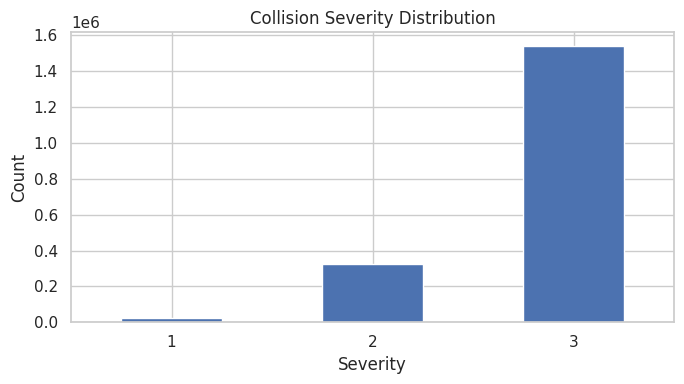

In [73]:
df['collision_severity'].value_counts().sort_index().plot(
    kind='bar',
    figsize=(7,4)
)
plt.title('Collision Severity Distribution')
plt.xlabel('Severity')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

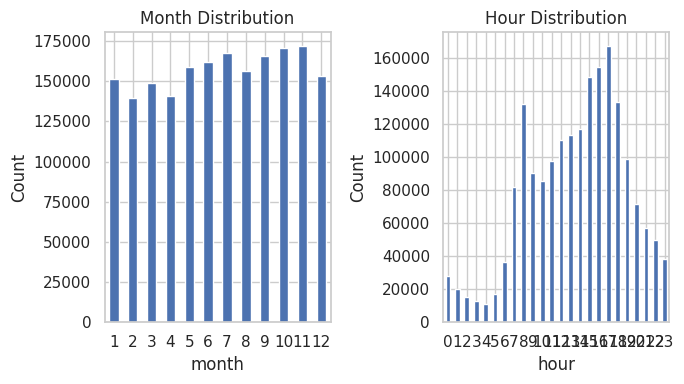

In [74]:
fig,axes = plt.subplots(1,2,figsize=(12,4))
for column, ax in zip(['month', 'hour'],axes):
  df[column].value_counts().sort_index().plot(
      kind='bar',
      ax=ax,
      figsize=(7,4)
  )
  ax.set_title(f'{column.capitalize()} Distribution')
  ax.set_xlabel(column)
  ax.set_ylabel('Count')
  ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

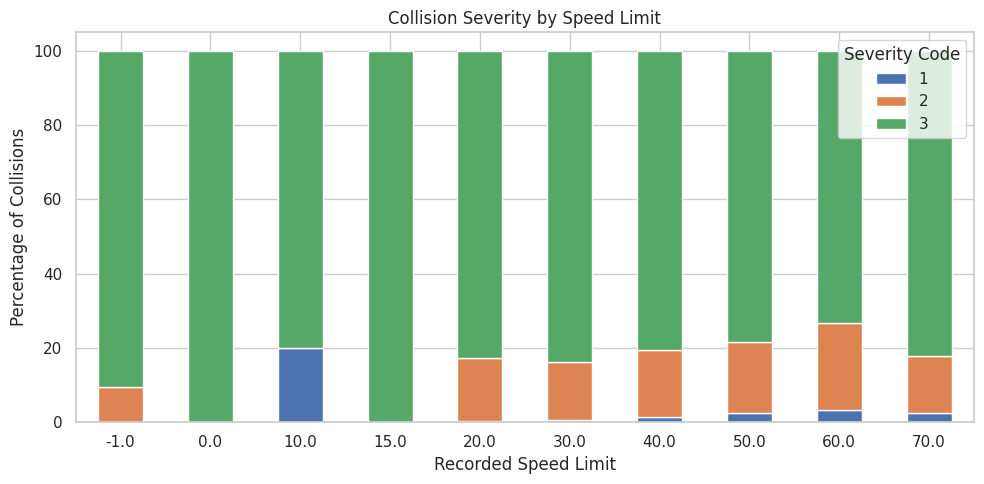

In [75]:
severity_by_speed = pd.crosstab(
    df['speed_limit'],
    df['collision_severity'],
    normalize='index'
) * 100

severity_by_speed.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 5)
)

plt.title('Collision Severity by Speed Limit')
plt.xlabel('Recorded Speed Limit')
plt.ylabel('Percentage of Collisions')
plt.legend(title='Severity Code')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [76]:
df.shape

(1886746, 42)

In [77]:
df.isna().sum().loc[lambda counts:counts > 0]

,0
location_easting_osgr,201
location_northing_osgr,201
longitude,201
latitude,201
local_authority_highway_current,287
speed_limit,37
average_driver_age,96877
average_vehicle_age,266533
max_vehicle_age,266533
most_common_vehicle_type,9744


In [78]:
df.drop(
    columns=[
        'local_authority_ons_district',
        'local_authority_highway',
        'local_authority_highway_current',
        'lsoa_of_accident_location',
        'first_road_number',
        'second_road_number'
    ],
    inplace=True
)

In [79]:
df.shape

(1886746, 36)

In [80]:
df.isnull().sum()

,0
collision_index,0
collision_year,0
location_easting_osgr,201
location_northing_osgr,201
longitude,201
latitude,201
police_force,0
collision_severity,0
number_of_vehicles,0
number_of_casualties,0


Save Final Dataset

Export the processed machine learning dataset. This dataset will be used during model training and evaluation.

In [81]:
df.to_csv('/content/drive/MyDrive/UK-Accident-Prediction/model_dataset.csv', index=False)

The three cleaned datasets were successfully integrated into a single machine learning dataset.

Summary of the work completed:

- Aggregated vehicle information at collision level.
- Aggregated casualty information at collision level.
- Merged the three cleaned datasets.
- Created additional temporal features.
- Performed exploratory data analysis.
- Verified the quality of the final dataset.
- Exported the processed dataset ready for model training.

In [82]:
print('Final Dataset Summary')
print('='*50)
print(f'Rows: {df.shape[0]}')
print(f'Columns: {df.shape[1]}')
print(f'Missing Values: {df.isnull().sum().sum()}')
print(f'Duplicate Rows: {df.duplicated().sum()}')

Final Dataset Summary
Rows: 1886746
Columns: 36
Missing Values: 694158
Duplicate Rows: 0
